
In this notebook i'm building baseline forecasting models and a machine learning model (XGBoost) with time-based validation.
---

## Load Feature Table

Load the cleaned feature table created in the data preparation phase.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb
import warnings

warnings.filterwarnings('ignore')

# set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [46]:
# load feature table
df = pd.read_csv('data/processed/walmart_features.csv')

# convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])


print("FEATURE TABLE")

print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nDate range: {df['Date'].min()} to {df['Date'].max()}")
print(f"\nSample rows:")
display(df.head())

print(f"\nBasic statistics:")
display(df[['Weekly_Sales', 'sales_lag_1', 'rolling_mean_4']].describe())

FEATURE TABLE
Shape: (394426, 25)

Columns: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'Year', 'Week', 'Month', 'sales_lag_1', 'sales_lag_2', 'sales_lag_4', 'sales_lag_8', 'rolling_mean_4', 'rolling_mean_8', 'Type', 'Size', 'sales_per_sqft', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

Date range: 2010-04-02 00:00:00 to 2012-10-26 00:00:00

Sample rows:


,Store,Dept,Date,Weekly_Sales,Year,Week,Month,sales_lag_1,sales_lag_2,sales_lag_4,sales_lag_8,rolling_mean_4,rolling_mean_8,Type,Size,sales_per_sqft,Temperature,Fuel_Price,CPI,Unemployment,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5
0,1,1,2010-04-02,57258.43,2010,13,4,26229.21,22136.64,21827.90,24924.50,22809.2850,27900.02750,A,151315,0.378406,62.27,2.719,210.820450,7.808,0.0,0.0,0.0,0.0,0.0
1,1,1,2010-04-09,42960.91,2010,14,4,57258.43,26229.21,21043.39,46039.49,31666.9175,31941.76875,A,151315,0.283917,65.86,2.770,210.622857,7.808,0.0,0.0,0.0,0.0,0.0
2,1,1,2010-04-16,17596.96,2010,15,4,42960.91,57258.43,22136.64,41595.55,37146.2975,31556.94625,A,151315,0.116294,66.32,2.808,210.488700,7.808,0.0,0.0,0.0,0.0,0.0
3,1,1,2010-04-23,16145.35,2010,16,4,17596.96,42960.91,26229.21,19403.54,36011.3775,28557.12250,A,151315,0.106700,64.84,2.795,210.439123,7.808,0.0,0.0,0.0,0.0,0.0
4,1,1,2010-04-30,16555.11,2010,17,4,16145.35,17596.96,57258.43,21827.90,33490.4125,28149.84875,A,151315,0.109408,67.41,2.780,210.389546,7.808,0.0,0.0,0.0,0.0,0.0



Basic statistics:


,Weekly_Sales,sales_lag_1,rolling_mean_4
count,394426.000000,394426.000000,394426.000000
mean,16136.192472,16132.769739,16132.010222
std,22789.876408,22784.205198,22262.480378
min,0.000000,0.000000,0.020000
25%,2185.270000,2185.572500,2250.391250
50%,7738.915000,7737.590000,7853.972500
75%,20416.587500,20409.602500,20500.546250
max,693099.360000,693099.360000,339472.757500


---
## Define Target and Inputs

Separate target variable from features, ensuring no data leakage.

In [47]:
# define target variable
target = 'Weekly_Sales'

# define features to exclude (identifiers, date, target)
exclude_features = ['Date', 'Store', 'Dept', 'Weekly_Sales']

# get feature columns
feature_cols = [col for col in df.columns if col not in exclude_features]

print("Target Variable:")
print(f"  Y = {target}")

print(f"\nFeature Variables ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

print(f"\nExcluded from features (to prevent leakage):")
print(f"  {exclude_features}")

# verify no leakage
print(f"\nBecause features do not include target or identifiers")

Target Variable:
  Y = Weekly_Sales

Feature Variables (21):
   1. Year
   2. Week
   3. Month
   4. sales_lag_1
   5. sales_lag_2
   6. sales_lag_4
   7. sales_lag_8
   8. rolling_mean_4
   9. rolling_mean_8
  10. Type
  11. Size
  12. sales_per_sqft
  13. Temperature
  14. Fuel_Price
  15. CPI
  16. Unemployment
  17. MarkDown1
  18. MarkDown2
  19. MarkDown3
  20. MarkDown4
  21. MarkDown5

Excluded from features (to prevent leakage):
  ['Date', 'Store', 'Dept', 'Weekly_Sales']

Because features do not include target or identifiers


---
## Time-Based Split

Split data by time to ensure realistic evaluation:
- **Train**: All weeks before 2012
- **Test**: All weeks in 2012

In [48]:
# time-based split
train = df[df['Year'] < 2012].copy()
test = df[df['Year'] == 2012].copy()


print("TIME-BASED TRAIN/TEST SPLIT")


print(f"\nTrain Set:")
print(f"  Shape: {train.shape}")
print(f"  Date range: {train['Date'].min()} to {train['Date'].max()}")
print(f"  Years: {sorted(train['Year'].unique())}")

print(f"\nTest Set:")
print(f"  Shape: {test.shape}")
print(f"  Date range: {test['Date'].min()} to {test['Date'].max()}")
print(f"  Years: {sorted(test['Year'].unique())}")

# verify no overlap
train_max_date = train['Date'].max()
test_min_date = test['Date'].min()

print(f"\nTemporal Validation:")
print(f"  Last train date: {train_max_date}")
print(f"  First test date: {test_min_date}")
print(f"  Gap: {(test_min_date - train_max_date).days} days")

if train_max_date < test_min_date:
    print("\nNo temporal overlap so it is a valid time-based split")
else:
    print("\nTemporal overlap detected!")

# split features and target
X_train = train[feature_cols]
y_train = train[target]
X_test = test[feature_cols]
y_test = test[target]

print(f"\nFeature matrices:")
print(f"  X_train: {X_train.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  X_test: {X_test.shape}")
print(f"  y_test: {y_test.shape}")

TIME-BASED TRAIN/TEST SPLIT

Train Set:
  Shape: (267735, 25)
  Date range: 2010-04-02 00:00:00 to 2011-12-30 00:00:00
  Years: [2010, 2011]

Test Set:
  Shape: (126691, 25)
  Date range: 2012-01-06 00:00:00 to 2012-10-26 00:00:00
  Years: [2012]

Temporal Validation:
  Last train date: 2011-12-30 00:00:00
  First test date: 2012-01-06 00:00:00
  Gap: 7 days

No temporal overlap so it is a valid time-based split

Feature matrices:
  X_train: (267735, 21)
  y_train: (267735,)
  X_test: (126691, 21)
  y_test: (126691,)


---
## Baseline Models

Build two simple baseline models to establish a performance benchmark.

### define evaluation metrics

In [49]:
def calculate_metrics(y_true, y_pred, model_name="Model"):
    """
    Calculate RMSE, MAPE, and WAPE for forecasting evaluation.
    
    RMSE: Root Mean Squared Error
    MAPE: Mean Absolute Percentage Error
    WAPE: Weighted Absolute Percentage Error
    """
    # remove any NaN predictions
    mask = ~np.isnan(y_pred)
    y_true_clean = y_true[mask]
    y_pred_clean = y_pred[mask]
    
    # rMSE
    rmse = np.sqrt(mean_squared_error(y_true_clean, y_pred_clean))
    
    # mAPE (avoid division by zero)
    mask_nonzero = y_true_clean != 0
    mape = np.mean(np.abs((y_true_clean[mask_nonzero] - y_pred_clean[mask_nonzero]) / y_true_clean[mask_nonzero])) * 100
    
    # wAPE
    wape = np.sum(np.abs(y_true_clean - y_pred_clean)) / np.sum(np.abs(y_true_clean)) * 100
    
    return {
        'Model': model_name,
        'RMSE': rmse,
        'MAPE': mape,
        'WAPE': wape
    }

print("Evaluation metrics we will use for forecasting: RMSE, MAPE, WAPE")

Evaluation metrics we will use for forecasting: RMSE, MAPE, WAPE


### baseline 1: naive forecast (last week's sales)

In [50]:
# naive baseline: use last week's sales
y_pred_naive = test['sales_lag_1'].values

# calculate metrics
metrics_naive = calculate_metrics(y_test.values, y_pred_naive, "Naive (Lag-1)")


print("BASELINE 1: NAIVE FORECAST")

print("Method: Use previous week's sales as prediction")
print(f"\nMetrics:")
print(f"  RMSE: {metrics_naive['RMSE']:,.2f}")
print(f"  MAPE: {metrics_naive['MAPE']:.2f}%")
print(f"  WAPE: {metrics_naive['WAPE']:.2f}%")

# sample predictions
print(f"\nSample predictions:")
comparison = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred_naive[:10],
    'Error': y_test.values[:10] - y_pred_naive[:10]
})
display(comparison)

BASELINE 1: NAIVE FORECAST
Method: Use previous week's sales as prediction

Metrics:
  RMSE: 3,951.78
  MAPE: 283.88%
  WAPE: 10.93%

Sample predictions:


,Actual,Predicted,Error
0,16567.69,23350.88,-6783.19
1,16894.40,16567.69,326.71
2,18365.10,16894.40,1470.70
3,18378.16,18365.10,13.06
4,23510.49,18378.16,5132.33
5,36988.49,23510.49,13478.00
6,54060.10,36988.49,17071.61
7,20124.22,54060.10,-33935.88
8,20113.03,20124.22,-11.19
9,21140.07,20113.03,1027.04


### baseline 2: rolling mean forecast

In [51]:
# rolling mean baseline: use 4-week rolling average
y_pred_rolling = test['rolling_mean_4'].values

# calculate metrics
metrics_rolling = calculate_metrics(y_test.values, y_pred_rolling, "Rolling Mean (4 weeks)")


print("BASELINE 2: ROLLING MEAN FORECAST")

print("Method: Use 4-week rolling average as prediction")
print(f"\nMetrics:")
print(f"  RMSE: {metrics_rolling['RMSE']:,.2f}")
print(f"  MAPE: {metrics_rolling['MAPE']:.2f}%")
print(f"  WAPE: {metrics_rolling['WAPE']:.2f}%")

# sample predictions
print(f"\nSample predictions:")
comparison = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred_rolling[:10],
    'Error': y_test.values[:10] - y_pred_rolling[:10]
})
display(comparison)

BASELINE 2: ROLLING MEAN FORECAST
Method: Use 4-week rolling average as prediction

Metrics:
  RMSE: 4,861.61
  MAPE: 1014.88%
  WAPE: 12.37%

Sample predictions:


,Actual,Predicted,Error
0,16567.69,37304.6450,-20736.9550
1,16894.40,33120.0875,-16225.6875
2,18365.10,25900.4300,-7535.3300
3,18378.16,18794.5175,-416.3575
4,23510.49,17551.3375,5959.1525
5,36988.49,19287.0375,17701.4525
6,54060.10,24310.5600,29749.5400
7,20124.22,33234.3100,-13110.0900
8,20113.03,33670.8250,-13557.7950
9,21140.07,32821.4600,-11681.3900


---
## XGBoost Forecasting Model

Train a gradient boosting model to capture complex patterns in the data.

In [52]:
# handle categorical features
# convert 'Type' to category codes because machine don't understand alphabets but only binaries
X_train_ml = X_train.copy()
X_test_ml = X_test.copy()

if 'Type' in X_train_ml.columns:
    X_train_ml['Type'] = X_train_ml['Type'].astype('category').cat.codes
    X_test_ml['Type'] = X_test_ml['Type'].astype('category').cat.codes
    print("Converted categorical feature 'Type' to numeric codes")

print(f"\nFeature matrix for ML:")
print(f"  X_train_ml: {X_train_ml.shape}")
print(f"  X_test_ml: {X_test_ml.shape}")

Converted categorical feature 'Type' to numeric codes

Feature matrix for ML:
  X_train_ml: (267735, 21)
  X_test_ml: (126691, 21)


In [53]:
# initialize XGBoost model
print("Training XGBoost model")

model_xgb = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

print("Model parameters:")
print(f"  n_estimators: 300")
print(f"  max_depth: 6")
print(f"  learning_rate: 0.05")
print(f"  subsample: 0.8")
print(f"  colsample_bytree: 0.8")

# train model
model_xgb.fit(X_train_ml, y_train)
print("Training complete")

Training XGBoost model
Model parameters:
  n_estimators: 300
  max_depth: 6
  learning_rate: 0.05
  subsample: 0.8
  colsample_bytree: 0.8
Training complete


In [54]:
# make predictions
y_pred_xgb = model_xgb.predict(X_test_ml)

print("Predictions generated")
print(f"  Predictions shape: {y_pred_xgb.shape}")
print(f"  Sample predictions: {y_pred_xgb[:5]}")

Predictions generated
  Predictions shape: (126691,)
  Sample predictions: [15851.292 16565.158 18296.018 18847.557 23126.553]


---
## Model Evaluation

Compare all three models using RMSE, MAPE, and WAPE.

In [55]:
# calculate XGBoost metrics
metrics_xgb = calculate_metrics(y_test.values, y_pred_xgb, "XGBoost")

# combine all metrics
results = pd.DataFrame([metrics_naive, metrics_rolling, metrics_xgb])


print("MODEL COMPARISON")
display(results)

# calculate improvements
print("\nXGBoost Improvement over Baselines:")

# vs Naive
rmse_improvement_naive = (metrics_naive['RMSE'] - metrics_xgb['RMSE']) / metrics_naive['RMSE'] * 100
mape_improvement_naive = (metrics_naive['MAPE'] - metrics_xgb['MAPE']) / metrics_naive['MAPE'] * 100
wape_improvement_naive = (metrics_naive['WAPE'] - metrics_xgb['WAPE']) / metrics_naive['WAPE'] * 100

print(f"vs Naive Baseline:")
print(f"  RMSE improvement: {rmse_improvement_naive:+.2f}%")
print(f"  MAPE improvement: {mape_improvement_naive:+.2f}%")
print(f"  WAPE improvement: {wape_improvement_naive:+.2f}%")

# vs Rolling Mean
rmse_improvement_rolling = (metrics_rolling['RMSE'] - metrics_xgb['RMSE']) / metrics_rolling['RMSE'] * 100
mape_improvement_rolling = (metrics_rolling['MAPE'] - metrics_xgb['MAPE']) / metrics_rolling['MAPE'] * 100
wape_improvement_rolling = (metrics_rolling['WAPE'] - metrics_xgb['WAPE']) / metrics_rolling['WAPE'] * 100

print(f"\nvs Rolling Mean Baseline:")
print(f"  RMSE improvement: {rmse_improvement_rolling:+.2f}%")
print(f"  MAPE improvement: {mape_improvement_rolling:+.2f}%")
print(f"  WAPE improvement: {wape_improvement_rolling:+.2f}%")

MODEL COMPARISON


,Model,RMSE,MAPE,WAPE
0,Naive (Lag-1),3951.778894,283.875504,10.933084
1,Rolling Mean (4 weeks),4861.613673,1014.875081,12.369428
2,XGBoost,1033.397900,624.673132,3.033221



XGBoost Improvement over Baselines:
vs Naive Baseline:
  RMSE improvement: +73.85%
  MAPE improvement: -120.05%
  WAPE improvement: +72.26%

vs Rolling Mean Baseline:
  RMSE improvement: +78.74%
  MAPE improvement: +38.45%
  WAPE improvement: +75.48%


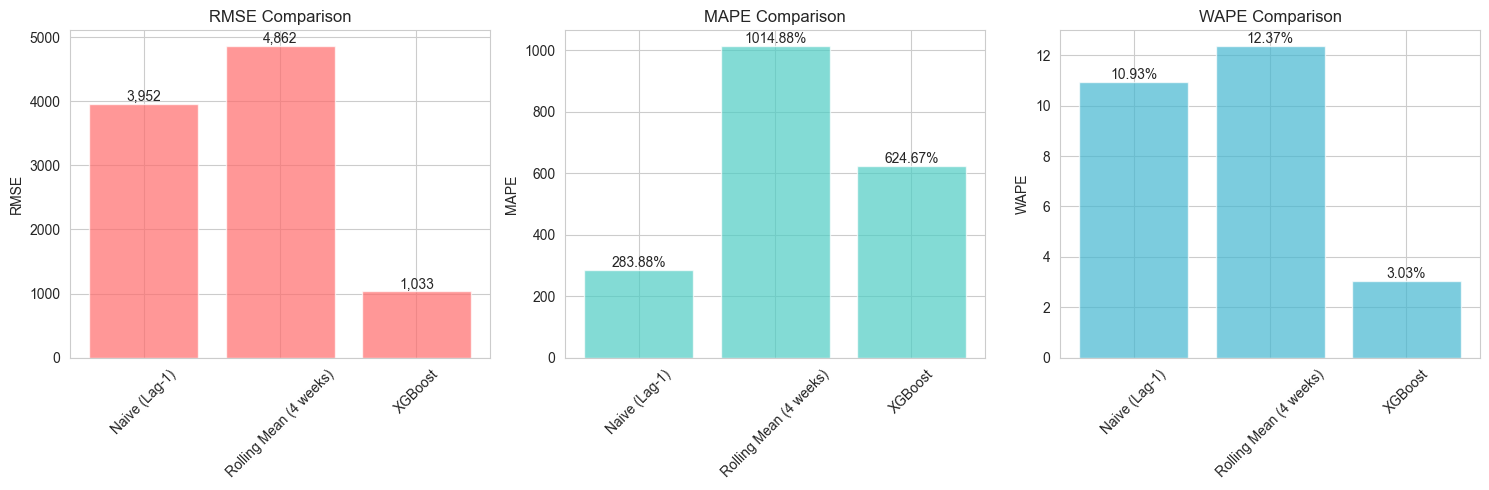

In [56]:
# visualize metric comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics_to_plot = ['RMSE', 'MAPE', 'WAPE']
colors = ['#fF6B6B', '#4ECDC4', '#45B7D1']

for idx, metric in enumerate(metrics_to_plot):
    axes[idx].bar(results['Model'], results[metric], color=colors[idx], alpha=0.7)
    axes[idx].set_ylabel(metric)
    axes[idx].set_title(f'{metric} Comparison')
    axes[idx].tick_params(axis='x', rotation=45)
    
    # add value labels on bars
    for i, v in enumerate(results[metric]):
        if metric == 'RMSE':
            axes[idx].text(i, v, f'{v:,.0f}', ha='center', va='bottom')
        else:
            axes[idx].text(i, v, f'{v:.2f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

---
## Visual Validation

Plot actual vs predicted for representative store-department combinations.

In [57]:
# add predictions to test dataframe
test_with_preds = test.copy()
test_with_preds['Pred_Naive'] = y_pred_naive
test_with_preds['Pred_Rolling'] = y_pred_rolling
test_with_preds['Pred_XGBoost'] = y_pred_xgb

# find high and low sales store-dept combinations
store_dept_avg = test.groupby(['Store', 'Dept'])['Weekly_Sales'].mean().reset_index()
store_dept_avg = store_dept_avg.sort_values('Weekly_Sales', ascending=False)

# select representatives
high_seller = store_dept_avg.iloc[0]  # highest average sales
low_seller = store_dept_avg.iloc[-1]  # lowest average sales
mid_seller = store_dept_avg.iloc[len(store_dept_avg)//2]  # medium seller

print("Selected Store-Department Combinations for Visualization:")
print(f"High Seller: Store {int(high_seller['Store'])}, Dept {int(high_seller['Dept'])} (Avg Sales: ${high_seller['Weekly_Sales']:,.2f})")
print(f"Mid Seller:  Store {int(mid_seller['Store'])}, Dept {int(mid_seller['Dept'])} (Avg Sales: ${mid_seller['Weekly_Sales']:,.2f})")
print(f"Low Seller:  Store {int(low_seller['Store'])}, Dept {int(low_seller['Dept'])} (Avg Sales: ${low_seller['Weekly_Sales']:,.2f})")

Selected Store-Department Combinations for Visualization:
High Seller: Store 13, Dept 92 (Avg Sales: $174,680.92)
Mid Seller:  Store 32, Dept 42 (Avg Sales: $6,931.23)
Low Seller:  Store 30, Dept 99 (Avg Sales: $0.02)


ValueError: '# fF6B6B' is not a valid value for color: supported inputs are (r, g, b) and (r, g, b, a) 0-1 float tuples; '#rrggbb', '#rrggbbaa', '#rgb', '#rgba' strings; named color strings; string reprs of 0-1 floats for grayscale values; 'C0', 'C1', ... strings for colors of the color cycle; and pairs combining one of the above with an alpha value

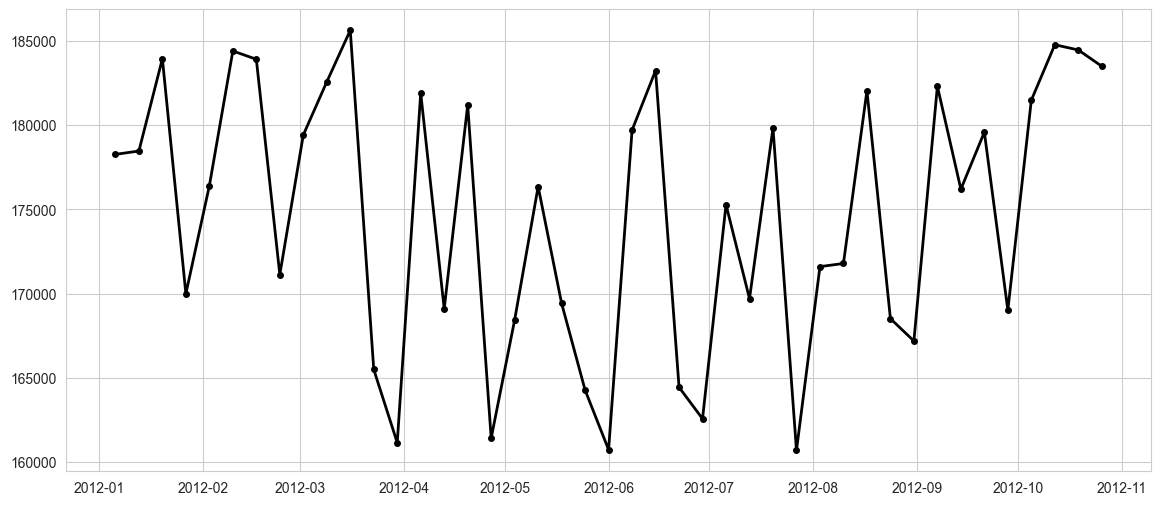

In [58]:
def plot_predictions(store, dept, title):
    """
    Plot actual vs predicted for a specific store-dept combination.
    """
    subset = test_with_preds[(test_with_preds['Store'] == store) & 
                              (test_with_preds['Dept'] == dept)].sort_values('Date')
    
    if len(subset) == 0:
        print(f"No data for Store {store}, Dept {dept}")
        return
    
    plt.figure(figsize=(14, 6))
    
    plt.plot(subset['Date'], subset['Weekly_Sales'], 
             marker='o', linewidth=2, markersize=4, label='Actual', color='black')
    plt.plot(subset['Date'], subset['Pred_Naive'], 
             marker='s', linewidth=1.5, markersize=3, label='Naive', alpha=0.7, color='# fF6B6B')
    plt.plot(subset['Date'], subset['Pred_Rolling'], 
             marker='^', linewidth=1.5, markersize=3, label='Rolling Mean', alpha=0.7, color='# 4ECDC4')
    plt.plot(subset['Date'], subset['Pred_XGBoost'], 
             marker='d', linewidth=1.5, markersize=3, label='XGBoost', alpha=0.7, color='# 45B7D1')
    
    plt.xlabel('Date')
    plt.ylabel('Weekly Sales ($)')
    plt.title(title)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # print metrics for this specific series
    print(f"\nMetrics for Store {int(store)}, Dept {int(dept)}:")
    
    actual = subset['Weekly_Sales'].values
    
    for model_name, pred_col in [('Naive', 'Pred_Naive'), 
                                   ('Rolling Mean', 'Pred_Rolling'), 
                                   ('XGBoost', 'Pred_XGBoost')]:
        pred = subset[pred_col].values
        metrics = calculate_metrics(actual, pred, model_name)
        print(f"{model_name:15s} - RMSE: {metrics['RMSE']:8,.2f}, MAPE: {metrics['MAPE']:6.2f}%, WAPE: {metrics['WAPE']:6.2f}%")

# plot for each selected combination
plot_predictions(int(high_seller['Store']), int(high_seller['Dept']), 
                 f"High Seller: Store {int(high_seller['Store'])}, Dept {int(high_seller['Dept'])}")

plot_predictions(int(mid_seller['Store']), int(mid_seller['Dept']), 
                 f"Mid Seller: Store {int(mid_seller['Store'])}, Dept {int(mid_seller['Dept'])}")

plot_predictions(int(low_seller['Store']), int(low_seller['Dept']), 
                 f"Low Seller: Store {int(low_seller['Store'])}, Dept {int(low_seller['Dept'])}")

---
## Residual Analysis

Analyze XGBoost residuals for uncertainty quantification in future work.

In [ ]:
# calculate residuals
residuals = y_test.values - y_pred_xgb


print("RESIDUAL ANALYSIS (XGBoost)")


# summary statistics
print(f"\nResidual Statistics:")
print(f"  Mean:     {np.mean(residuals):12,.2f}")
print(f"  Std Dev:  {np.std(residuals):12,.2f}")
print(f"  Min:      {np.min(residuals):12,.2f}")
print(f"  Max:      {np.max(residuals):12,.2f}")
print(f"  Median:   {np.median(residuals):12,.2f}")

print(f"\nPercentiles:")
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
for p in percentiles:
    value = np.percentile(residuals, p)
    print(f"  {p:2d}th: {value:12,.2f}")

RESIDUAL ANALYSIS (XGBoost)

Residual Statistics:
  Mean:           -21.76
  Std Dev:      1,033.17
  Min:        -38,410.64
  Max:         30,995.35
  Median:         -18.60

Percentiles:
   1th:    -3,161.46
   5th:    -1,082.03
  10th:      -657.97
  25th:      -239.81
  50th:       -18.60
  75th:       176.26
  90th:       645.57
  95th:     1,118.30
  99th:     2,746.36


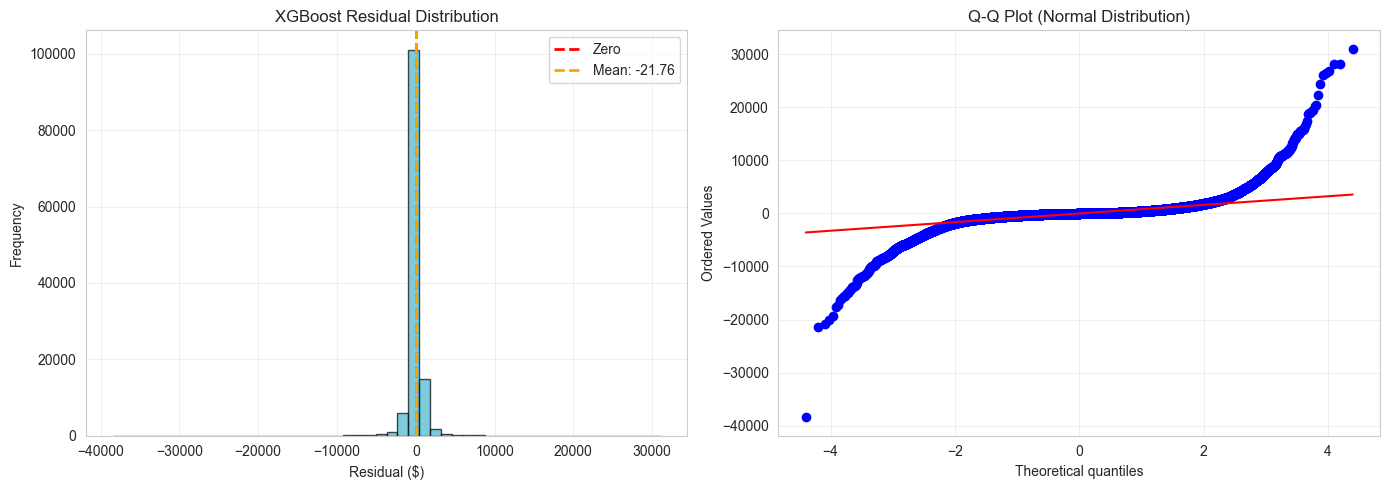


Shapiro-Wilk Test for Normality (sample):
  p-value: 0.0000
Residuals may not be normally distributed (p ≤ 0.05)


In [ ]:
# visualize residual distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
axes[0].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='#45B7D1')
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero')
axes[0].axvline(np.mean(residuals), color='orange', linestyle='--', linewidth=2, label=f'Mean: {np.mean(residuals):.2f}')
axes[0].set_xlabel('Residual ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('XGBoost Residual Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# q-Q plot (Quantile-Quantile)
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot (Normal Distribution)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# test for normality
_, p_value = stats.shapiro(residuals[:5000])  # sample for Shapiro-Wilk test
print(f"\nShapiro-Wilk Test for Normality (sample):")
print(f"  p-value: {p_value:.4f}")
if p_value > 0.05:
    print("Residuals appear normally distributed (p > 0.05)")
else:
    print("Residuals may not be normally distributed (p ≤ 0.05)")

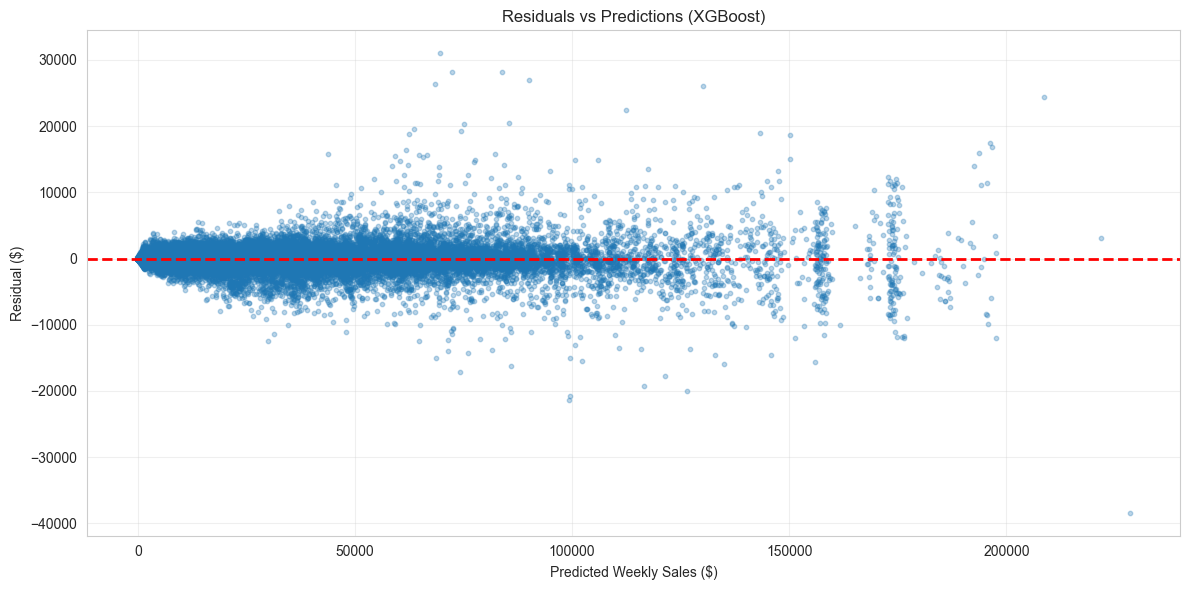


Residual analysis complete


In [ ]:
# residuals vs Predictions scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(y_pred_xgb, residuals, alpha=0.3, s=10)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Weekly Sales ($)')
plt.ylabel('Residual ($)')
plt.title('Residuals vs Predictions (XGBoost)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nResidual analysis complete")

### save predictions and residuals

In [59]:
# create results dataframe
results_df = test[['Store', 'Dept', 'Date', 'Weekly_Sales']].copy()
results_df['Pred_Naive'] = y_pred_naive
results_df['Pred_Rolling'] = y_pred_rolling
results_df['Pred_XGBoost'] = y_pred_xgb
results_df['Residual_XGBoost'] = residuals

# save to CSV
output_path = 'data/processed/model_predictions_and_residuals.csv'
results_df.to_csv(output_path, index=False)


print("RESULTS SAVED")

print(f"File: {output_path}")
print(f"Rows: {len(results_df):,}")
print(f"Columns: {list(results_df.columns)}")
print(f"\nSample:")
display(results_df.head())

print("\nPredictions and residuals saved for future uncertainty quantification")

RESULTS SAVED
File: data/processed/model_predictions_and_residuals.csv
Rows: 126,691
Columns: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'Pred_Naive', 'Pred_Rolling', 'Pred_XGBoost', 'Residual_XGBoost']

Sample:


,Store,Dept,Date,Weekly_Sales,Pred_Naive,Pred_Rolling,Pred_XGBoost,Residual_XGBoost
92,1,1,2012-01-06,16567.69,23350.88,37304.6450,15851.291992,716.398008
93,1,1,2012-01-13,16894.40,16567.69,33120.0875,16565.158203,329.241797
94,1,1,2012-01-20,18365.10,16894.40,25900.4300,18296.017578,69.082422
95,1,1,2012-01-27,18378.16,18365.10,18794.5175,18847.556641,-469.396641
96,1,1,2012-02-03,23510.49,18378.16,17551.3375,23126.552734,383.937266



Predictions and residuals saved for future uncertainty quantification
